In [1]:
# load gaussian_annealing_naive_unweighted
import os
import pickle
import sys 

sys.path.append('.')
sys.path.append('..')
sys.path.append('../data')
# from src.plotting import create_all_plots

# print(os.listdir('../data'))

# data = pickle.load(open('polynomial/double_well/leapfrog/cd_unweighted.pkl', 'rb'))


In [2]:
# data['snapshots']['times']

4000.0
empirical expectation 1.0563967


/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_50509/543567618.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho = rho / np.trapz(rho, x)  # Normalize


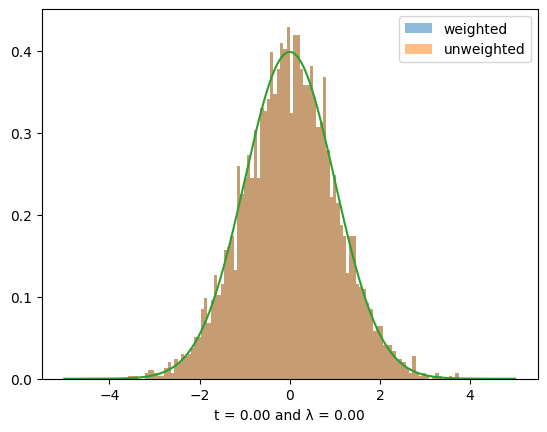

3730.3108
empirical expectation 0.558123


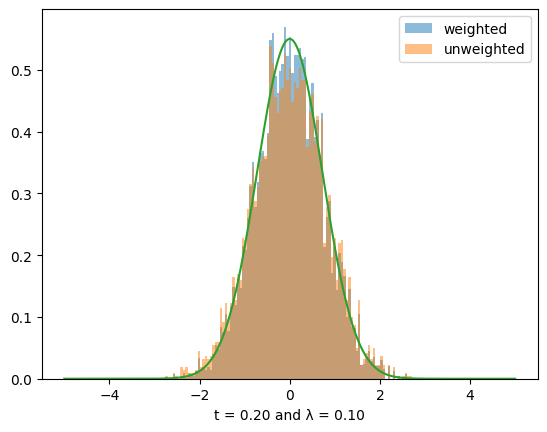

3429.4675
empirical expectation 0.36424035


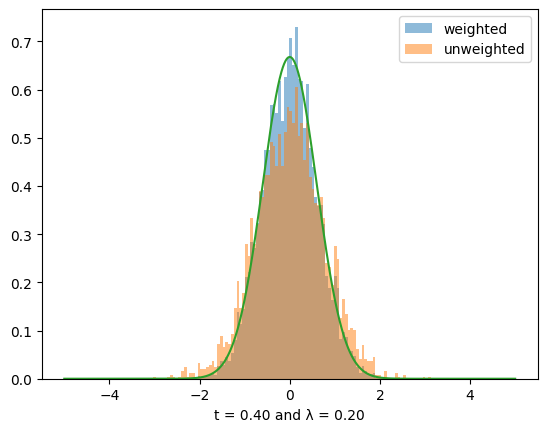

3184.484
empirical expectation 0.27051774


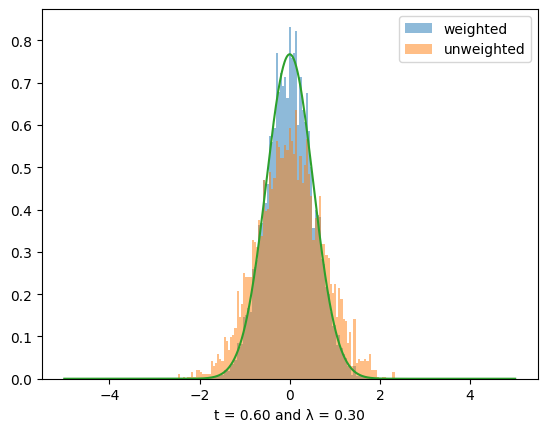

2976.8765
empirical expectation 0.21644054


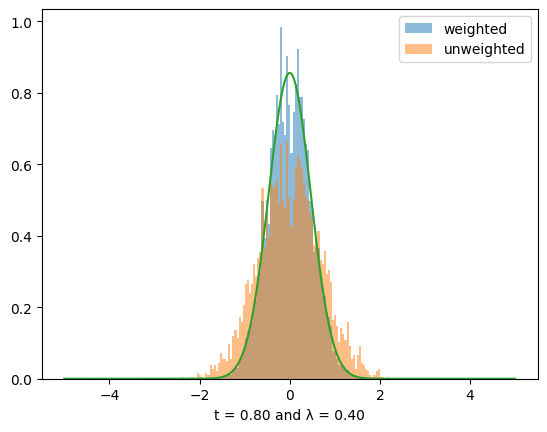

2802.57
empirical expectation 0.18307234


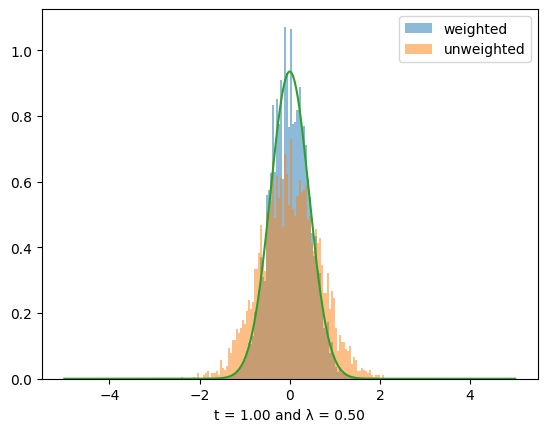

2655.562
empirical expectation 0.15980557


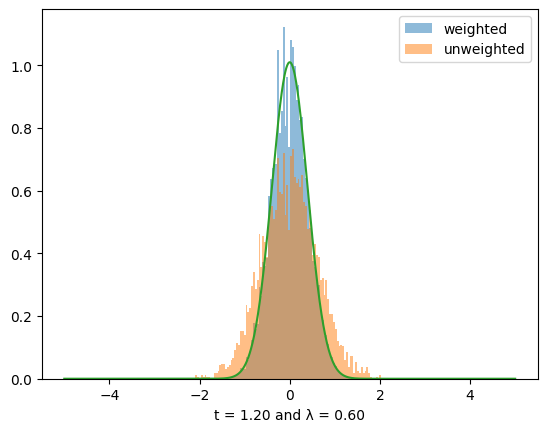

2529.5112
empirical expectation 0.1408085


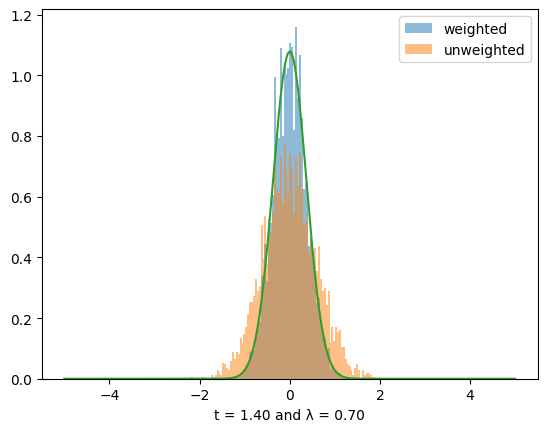

2420.3345
empirical expectation 0.12433748


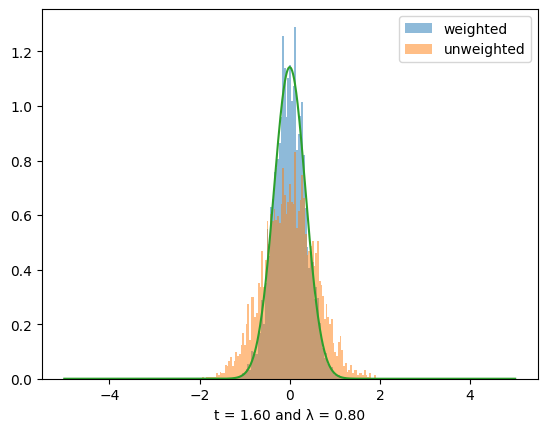

2324.696
empirical expectation 0.111056


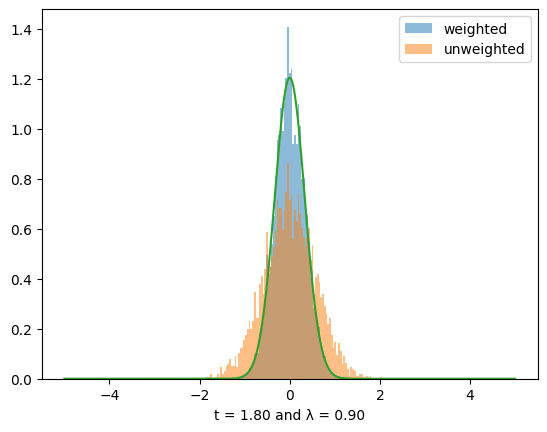

2239.8118
empirical expectation 0.101467535


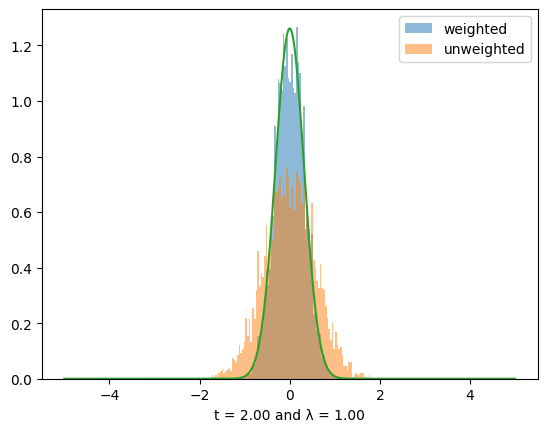

cost: 44000


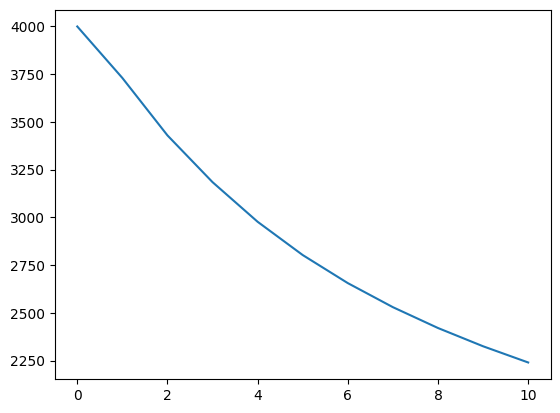

In [8]:
# plot a gaussian with unit variance, 1D
import numpy as np
import matplotlib.pyplot as plt
from src.systems import SYSTEMS
import jax.numpy as jnp
# y is a normal pdf (scipy) with std 0.1
from scipy.stats import norm
from src.utils import compute_ess, compute_expectation_over_equilibrium, normalize_log_weights
# y = norm.pdf(x, 0, 1/0.5)



def make_hist(file, system_name):
    data = pickle.load(open(file, 'rb'))

    x = np.linspace(-5, 5, 1000)


    times = data['snapshots']['times']
    N = len(times)
    M = data['snapshots']['particles'][0].shape[0]
    lambdas = data['snapshots']['lam']
    esses = []
    for i in range(len(data['snapshots']['particles'])):
    # for i in range(1):
        potential = SYSTEMS[system_name]['make_V'](lambdas[i])


        y = potential(x)
        # normalize y using trapezoid integration
        rho = np.array([np.exp(-potential(point)) for point in x])
        rho = rho / np.trapz(rho, x)  # Normalize

        # print(times[i])

        particles = data['snapshots']['particles'][i]
        log_weights = data['snapshots']['weights'][i]
        weights = np.exp(normalize_log_weights(log_weights))
        
        all_weights = np.exp(data['snapshots']['weights'])
        all_weights = jnp.clip(all_weights, 0, 1).mean(axis=-1)

        # compute ess of weights 
        ess = compute_ess(log_weights)
        print(ess)
        esses.append(ess)

        # expect = jnp.sum(weights * (particles**2)[:, 0], axis=0)
        # print(expect, "expectation", weights.shape, particles.shape, (weights * (particles**2)[:, 0]).shape)

        empirical_e = compute_expectation_over_equilibrium(particles[:, 0]**2, log_weights)
        print("empirical expectation",empirical_e)

        # all_weights = all_weights.mean(axis=-1)
        
        num_bins = 100
        plt.hist(particles[:,0], bins=num_bins, weights=weights, density=True, alpha=0.5, label='weighted')
        plt.hist(particles[:,0], bins=num_bins, density=True, alpha=0.5, label='unweighted')
        plt.plot(x, rho)
        plt.xlabel(f't = {times[i]:.2f} and λ = {lambdas[i]:.2f}')
        plt.legend()
        plt.show()
        plt.clf()


    # plt.plot(all_weights)
    # print(data)
    # plt.show()
    plt.plot(esses)

    true_expectation = 0.1
    error = ((empirical_e - true_expectation)**2) / (2 * true_expectation)
    # print(f'error: {error} and ESS: {100/error}')
    cost_per_step = 1
    cost = cost_per_step * N * M 
    print(f'cost: {cost}')



# error_cd, estimate_cd = calculate_normalized_error(
#                     final_samples_cd, true_exp, true_var, f_func
#                 )


system_name = 'gaussian_annealing'
# system_name = 'double_well'

# make_hist(file='naive/double_well/leapfrog/naive_weighted.pkl', i=0)
# make_hist(file='naive/double_well/leapfrog/naive_unweighted.pkl', i=20)
# make_hist(file='naive/double_well/leapfrog/naive_weighted.pkl', i=20)
# make_hist(file='polynomial/double_well/leapfrog/cd_unweighted.pkl', i=20)
# make_hist(file='polynomial/double_well/leapfrog/cd_weighted.pkl', i=20)
make_hist(file=f'polynomial/{system_name}/leapfrog/cd_weighted.pkl', system_name=system_name)
# make_hist(file=f'naive/{system_name}/leapfrog/naive_weighted.pkl', system_name=system_name)

In [6]:
from src.simple_benchmark import calculate_double_well_expectations


true_expectations = calculate_double_well_expectations(2.0)
true_expectations

{'x_squared': {'expectation': 14.6827908, 'variance': 17.694268}}